<a href="https://colab.research.google.com/github/luc-polo/Machine-Learning-Practice-practicals/blob/main/website/public/modules/ms2a-machine-learning-practice/challenges/mlp-s5-blood-cells.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blood Cell Classification — starter notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/data_science_practice/blob/main/website/public/modules/ms2a-machine-learning-practice/challenges/mlp-s5-blood-cells.ipynb)

Classify microscopy images of **blood cells** into one of **8 cell types**, from
28×28 RGB images: [challenge 173](https://ml-arena.com/viewchallenge/173) on ML-Arena.

This notebook runs end-to-end: **download the data → look at it → train a simple model → submit**.
Metric: **F1-macro**.

> Open in Colab, then run the cells top to bottom. The only thing you must edit is
> your API token in the next cell (find it on your **Profile** page on ml-arena.com).

## 0. Setup

In [8]:
!pip install -q "mlarena-sdk>=3" scikit-learn pandas numpy  # installs the `mlarena` package

import mlarena
import numpy as np
import pandas as pd

API_TOKEN = "mlk_user_be8edd1568655ff0_bbfbb4ff5c006ef6b5f81d63b919a32c"   # <-- paste your token (Profile page)
CHALLENGE_ID = 173

client = mlarena.connect(api_key=API_TOKEN, base_url="https://ml-arena.com")

zsh:1: command not found: pip


## 1. Get the data

`download_dataset` pulls the challenge files into `data/`. Each image is a
`28 × 28 × 3` (RGB) array; the training labels are in `y_train.csv` (`image_id,label`).

In [3]:


train = np.load("data/train_images.npz")   # train["image_id"], train["images"] (N,28,28,3) uint8
test  = np.load("data/test_images.npz")    # test["image_id"],  test["images"]
y_train = pd.read_csv("data/y_train.csv")  # image_id,label

# line up each image with its label (match on image_id, don't assume row order)
label_of = y_train.set_index("image_id")["label"]
y = label_of.loc[train["image_id"]].values

print("train images:", train["images"].shape, "  test images:", test["images"].shape)
print(pd.Series(y).value_counts())

train images: (13673, 28, 28, 3)   test images: (3419, 28, 28, 3)
cell_C    2663
cell_B    2494
cell_F    2316
cell_A    1878
cell_D    1241
cell_H    1136
cell_G     974
cell_E     971
Name: count, dtype: int64


## 2. Look at the images

Six random training images per class, one row per cell type, with the number of
training images of that class. The rows differ in nucleus shape, granularity and
stain colour; the counts show how unbalanced the classes are, which is why the
metric is F1-macro.


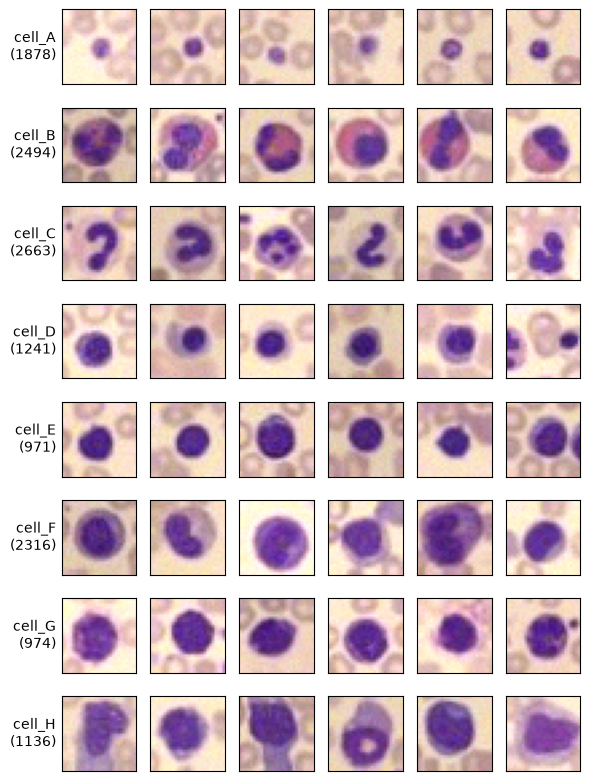

In [11]:
import matplotlib.pyplot as plt

classes = sorted(np.unique(y))
rng = np.random.default_rng(19)
fig, axes = plt.subplots(len(classes), 6, figsize=(6, len(classes)))
for row, cls in zip(axes, classes):
    idx = rng.choice(np.flatnonzero(y == cls), size=6, replace=False)
    for ax, i in zip(row, idx):
        ax.imshow(train["images"][i])
        ax.set_xticks([]); ax.set_yticks([])
    row[0].set_ylabel(f"{cls}\n({(y == cls).sum()})", rotation=0, ha="right", va="center")
plt.tight_layout()
plt.show()


## 3. A baseline model

Flatten each image into a vector of pixels and fit a random forest. This is just a
starting point — a small CNN (e.g. PyTorch) trained on the raw images will score
much higher. We hold out 20% to estimate the F1-macro before submitting.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X = train["images"].reshape(len(train["images"]), -1) / 255.0   # (N, 28*28*3)
X_test = test["images"].reshape(len(test["images"]), -1) / 255.0

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
clf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0)
clf.fit(X_tr, y_tr)
print("validation F1-macro: %.4f" % f1_score(y_val, clf.predict(X_val), average="macro"))

clf.fit(X, y)   # refit on all the training data before predicting the test set

validation F1-macro: 0.7393


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 4. Predict and write `submission.csv`

In [6]:
pred = clf.predict(X_test)
submission = pd.DataFrame({"image_id": test["image_id"], "label": pred})
submission.to_csv("submission.csv", index=False)
submission.head()

,image_id,label
0,img_002591,cell_C
1,img_001828,cell_D
2,img_015622,cell_G
3,img_010608,cell_F
4,img_008013,cell_F


## 5. Submit

Run the cell below to submit through the SDK, or upload `submission.csv` on the
challenge page.

In [29]:
result = client.submit(challenge_id=CHALLENGE_ID, files=["submission.csv"])
print(result)

{'submission_id': 9060, 'deploy': {'deployment_id': 8772, 'is_deployable': False, 'is_settled': False, 'is_uploadable': False, 'last_status_message': 'Deployment queued successfully', 'message': 'Deployment started successfully', 'phase': 'deployment', 'status': 'deploy_queue', 'status_update_ts': '2026-09-28T14:27:21.507413Z'}}


## 6. Where to go from here

The pixel-flattening baseline throws away the *spatial* structure of the image — that's
where most of the score is hiding. Work one step at a time: **change one thing → watch the
validation F1 → submit only if it improved.** Trust the held-out number, not the train score.

- **Look at more images.** Rerun the grid of section 2 with other seeds and look for anything odd — blurry crops, near-duplicates,
  mislabeled cells. F1-macro weights every class equally, so the rare ones matter most.

- **Train a small CNN (PyTorch).** A couple of conv + pooling layers already beats the random
  forest by a wide margin, because convolutions exploit the 2-D layout the baseline discards.
  Normalize inputs to `[0, 1]` (or per-channel mean/std) and use cross-entropy loss.

- **Train carefully.** Keep a stratified validation split and watch it every epoch.
  - *Learning rate* is the single most important knob — try a few values (e.g. 1e-2 … 1e-4).
  - Use **early stopping** and save the best-validation checkpoint.
  - Tune batch size and epochs; add dropout or weight decay if you overfit.

- **Augment the data.** Random flips, small rotations, and mild color jitter make the model
  robust to orientation and staining differences — cheap and almost always helps on microscopy.

- **Use a pretrained model.** Load a network pretrained on ImageNet (ResNet, EfficientNet, …),
  resize the 28×28 crops to its expected input, and **fine-tune** it on these cells. This is
  usually the biggest jump for the least effort.

Watch train vs. validation: if validation stalls while train keeps improving, you're
overfitting — stop early, augment more, or regularize.


## CNN training

In [34]:
# Train a CNN

import torch
from torch import nn
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device", device)
class CNN(nn.Sequential):
    def __init__(self, num_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
            )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, num_classes))
    def forward(self, x):
        return self.classifier(self.features(x))


model = CNN(num_classes=8).to(device)

images = torch.tensor(X_tr.reshape(-1, 28, 28, 3), dtype=torch.float32).permute(0, 3, 1, 2)
labels = torch.tensor(np.searchsorted(classes, y_tr), dtype=torch.long)
from torchvision import transforms as T
augment = T.Compose([T.RandomHorizontalFlip(), T.RandomVerticalFlip(), T.RandomResizedCrop(28, scale=(0.8, 1.0), ratio=(1.0, 1.0)), T.RandomRotation(20)])
images = torch.cat([images, torch.stack([augment(img) for img in images])])
labels = labels.repeat(2)
loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(images, labels), batch_size=32, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model.train()
for epoch in range(10):
    epoch_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = nn.CrossEntropyLoss()(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    print(f"Epoch {epoch + 1}/10 — loss: {epoch_loss / len(loader.dataset):.4f}")

model.eval()
with torch.no_grad():
    x_val = torch.tensor(X_val.reshape(-1, 28, 28, 3), dtype=torch.float32).permute(0, 3, 1, 2).to(device)
    predictions = model(x_val).argmax(dim=1).cpu().numpy()
print("F1 macro :", f1_score(y_val, np.array(classes)[predictions], average="macro"))


device mps
Epoch 1/10 — loss: 0.6429
Epoch 2/10 — loss: 0.3999
Epoch 3/10 — loss: 0.3442
Epoch 4/10 — loss: 0.3068
Epoch 5/10 — loss: 0.2858
Epoch 6/10 — loss: 0.2682
Epoch 7/10 — loss: 0.2537
Epoch 8/10 — loss: 0.2370
Epoch 9/10 — loss: 0.2273
Epoch 10/10 — loss: 0.2204
F1 macro : 0.8858650337877583


In [28]:
model.eval()
with torch.no_grad():
    x_test = torch.tensor(X_test.reshape(-1, 28, 28, 3), dtype=torch.float32).permute(0, 3, 1, 2).to(device)
    pred = np.array(classes)[model(x_test).argmax(dim=1).cpu().numpy()]

submission = pd.DataFrame({"image_id": test["image_id"], "label": pred})
submission.to_csv("submission.csv", index=False)
submission.head()

,image_id,label
0,img_002591,cell_C
1,img_001828,cell_D
2,img_015622,cell_G
3,img_010608,cell_F
4,img_008013,cell_G


In [50]:

from torchvision.models import resnet18, ResNet18_Weights
from itertools import chain
import random as pyrandom

seed = 42
pyrandom.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(seed)

weights = ResNet18_Weights.DEFAULT
preprocess = weights.transforms()
efficientnet = resnet18(weights=weights)
efficientnet.fc = nn.Linear(efficientnet.fc.in_features, len(classes))
efficientnet = efficientnet.to(device)



optimizer_efficientnet = torch.optim.AdamW([
    {"params": chain(efficientnet.conv1.parameters(), efficientnet.bn1.parameters(),
                     efficientnet.layer1.parameters()), "lr": 5e-6},
    {"params": chain(efficientnet.layer2.parameters(),
                     efficientnet.layer3.parameters()), "lr": 5e-6},
    {"params": efficientnet.layer4.parameters(), "lr": 5e-5},
    {"params": efficientnet.fc.parameters(), "lr": 5e-5},
], weight_decay=1e-3)

# Keep the originals and add one augmented copy of each training image.
train_images = torch.tensor(X_tr.reshape(-1, 28, 28, 3), dtype=torch.float32).permute(0, 3, 1, 2)
train_labels = torch.tensor(np.searchsorted(classes, y_tr), dtype=torch.long)
train_images = torch.cat([train_images, torch.stack([augment(img) for img in train_images])])
train_labels = train_labels.repeat(2)
loader_efficientnet = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(train_images, train_labels), batch_size=32, shuffle=True)

val_images = torch.tensor(X_val.reshape(-1, 28, 28, 3), dtype=torch.float32).permute(0, 3, 1, 2)

class_weights = torch.tensor([1 / (y_tr == c).sum() for c in classes], dtype=torch.float32, device=device)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_efficientnet, mode="max", factor=0.5, patience=1, threshold=0)
best_f1, epochs_without_improvement = -float("inf"), 0

for epoch in range(6):
    efficientnet.train()
    epoch_loss = 0.0
    for xb, yb in loader_efficientnet:
        xb, yb = xb.to(device), yb.to(device)
        xb = preprocess(xb)
        optimizer_efficientnet.zero_grad()
        loss = nn.CrossEntropyLoss(weight=class_weights)(efficientnet(xb), yb)
        loss.backward()
        optimizer_efficientnet.step()
        epoch_loss += loss.item() * xb.size(0)

    efficientnet.eval()
    with torch.no_grad():
        predictions = np.concatenate([
            efficientnet(preprocess(xb.to(device))).argmax(1).cpu().numpy()
            for xb in val_images.split(32)
        ])
    score = f1_score(y_val, np.array(classes)[predictions], average="macro")
    print(f"Epoch {epoch + 1}/6 — loss: {epoch_loss / len(loader_efficientnet.dataset):.4f} — F1: {score:.4f}")
    scheduler.step(score)
    if score > best_f1:
        best_f1, epochs_without_improvement = score, 0
        torch.save(efficientnet.state_dict(), "resnet_best.pt")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= 3:
            print("Early stopping: no validation F1 improvement for 3 epochs.")
            break

efficientnet.load_state_dict(torch.load("resnet_best.pt", map_location=device, weights_only=True))
print(f"Best validation F1 restored: {best_f1:.4f}")


Epoch 1/6 — loss: 0.5064 — F1: 0.8804
Epoch 2/6 — loss: 0.2073 — F1: 0.9079
Epoch 3/6 — loss: 0.1033 — F1: 0.9060
Epoch 4/6 — loss: 0.0511 — F1: 0.9197
Epoch 5/6 — loss: 0.0276 — F1: 0.9142
Epoch 6/6 — loss: 0.0219 — F1: 0.9100
Best validation F1 restored: 0.9197


In [47]:
efficientnet.eval()  # Cette variable contient maintenant ResNet
with torch.no_grad():
    pred = np.concatenate([efficientnet(preprocess(xb.to(device))).argmax(1).cpu().numpy() for xb in val_images.split(32)])

for classe, f1 in zip(classes, f1_score(y_val, np.array(classes)[pred], labels=classes, average=None, zero_division=0)):
    print(f"{classe} : {f1:.4f}")
    

cell_A : 0.9934
cell_B : 0.9920
cell_C : 0.9687
cell_D : 0.9256
cell_E : 0.9231
cell_F : 0.8630
cell_G : 0.8804
cell_H : 0.8430
